# Omni Stick — Early Stumble & Fall Detection

Predicts a fall **before** impact from IMU (motion sensor) data, using the KFall dataset.

**Pipeline:** load KFall CSVs → slice into windows → label windows shortly *before* fall onset as "at risk" → train a small 1D-CNN → evaluate → shrink to `.tflite` for the stick's microcontroller → plot the "it saw it coming" timeline.

> Run cells top to bottom.

## 1. Setup

In [7]:
!pip install numpy pandas scikit-learn tensorflow matplotlib -q
#installs the toolboxes we need. -q means quiet, don't print a huge wall of install logs
import numpy as np #numpy: working with arrays of numbers efficiently
import pandas as pd #reading and handling table-like data
import tensorflow as tf #building and training the neural network
from sklearn.model_selection import train_test_split #scikit-learn: helper tools, like splitting data and measuring how good the model is
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt #drawing graphs
import glob, os #finding files on disk and working with file paths

print("TensorFlow:", tf.__version__)

#Basically -> loading the toolbox

TensorFlow: 2.20.0


## 2. Get the data in

Using the [KFall dataset mirror on Kaggle](https://www.kaggle.com/datasets/usmanabbasi2002/kfall-dataset) — no access-request wait, downloads straight into Colab.


In [8]:
import os

KAGGLE_TOKEN = "KGAT_ddce98b3aeda917b83a3b3b1b97fd59f"
# Saves your Kaggle login key to a specific hidden folder (~/.kaggle/) that
# Kaggle's download tool automatically checks
# It's like typing in a password once so the tool can use it later without
# asking again.

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/access_token"), "w") as f:
    f.write(KAGGLE_TOKEN)
os.chmod(os.path.expanduser("~/.kaggle/access_token"), 0o600)

!pip install kaggle -q
print("Token saved.")

Token saved.


In [9]:
DATA_DIR = "/content/kfall"

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    !kaggle datasets download -d usmanabbasi2002/kfall-dataset -p $DATA_DIR --unzip
    # command-line instruction (that's what the ! means — "run this like a terminal command, not Python").
    # It tells Kaggle's tool: "Download this specific dataset, put it in this folder, and unzip it automatically."

print("Files found:", len(glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True)))

Files found: 5075


## 3. Load one trial

Before processing everything, look at a single file to confirm the column names match what we expect.

In [10]:
sample_files = glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True)
# Same search as before, but this time we keep the actual list of file paths (not just the count), so we can open one of them next.
df_sample = pd.read_csv(sample_files[0])
# Opens the very first file in that list as a table (a "DataFrame" in pandas language).
print(df_sample.columns.tolist())
df_sample.head()
# .columns.tolist() prints the column headers, so you can see what data is actually inside.
# .head() shows the first few rows, so you can see what the numbers look like.

['TimeStamp(s)', 'FrameCounter', 'AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY', 'GyrZ', 'EulerX', 'EulerY', 'EulerZ']


,TimeStamp(s),FrameCounter,AccX,AccY,AccZ,GyrX,GyrY,GyrZ,EulerX,EulerY,EulerZ
0,0.01,1,-0.099,-1.001,0.217,1.604282,-0.630254,0.744845,99.562912,-3.982058,0.240642
1,0.02,2,-0.116,-0.997,0.244,0.572958,-1.604282,2.177240,99.574371,-3.999247,0.217724
2,0.03,3,-0.123,-0.984,0.256,0.057296,-0.458366,2.234536,99.574371,-4.022165,0.211994
3,0.04,4,-0.123,-0.977,0.270,0.572958,0.974029,2.291832,99.580100,-4.045083,0.217724
4,0.05,5,-0.117,-0.981,0.266,0.859437,2.807494,2.177240,99.625937,-4.090920,0.240642


In [11]:
SENSOR_COLS = ['AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY', 'GyrZ']

WINDOW_SIZE = 100   # 1 second at 100Hz (confirmed from TimeStamp(s) column: 0.01s steps)
STEP = 20            # slide the window forward by 20 readings each time
LEAD_TIME = 40        # label a window "at risk" if it ends within this many frames before fall onset

# Real KFall folder layout (confirmed from the download):
#   sensor_data/SA16/S16T24R03.csv        <- subject SA16, task T24, trial R03
#   label_data/SA16_label.xlsx            <- one label file per subject, all their trials

LABEL_DIR = glob.glob(f"{DATA_DIR}/**/label_data", recursive=True)[0]
print("Label folder:", LABEL_DIR)

Label folder: /content/kfall/KFall Dataset/KFall Dataset/label_data


## 4. Windowing

Chops a long recording into overlapping short clips — the model looks at short snapshots of movement, not the whole recording at once.

In [5]:
def make_windows(signal, window_size, step):
  # Defines a reusable function. signal = the sensor readings for one trial,
    # window_size = how many readings go in one "clip" (100 = 1 second), step =
    # how far to slide forward before cutting the next clip (20 readings).
    """Slice a (T, C) signal array into overlapping windows of shape (window_size, C)."""
    windows = []
    end_indices = []
    for start in range(0, len(signal) - window_size, step):
        windows.append(signal[start:start + window_size])
        end_indices.append(start + window_size)
    return np.array(windows), np.array(end_indices)
    # windows = [] and end_indices = [] → start with two empty lists to fill up
    # The for loop walks through the signal in jumps of step (20), and each time, it slices out a chunk of window_size (100) readings: signal[start:start+window_size]
    # It saves that chunk into windows, and separately remembers when that chunk ended (end_indices) — this matters later for labeling
    # return np.array(...) converts the Python lists into numpy arrays, which
    # are much faster to work with

    # Cut one long recording into hundreds of little overlapping 1-second clips, and
    # remember exactly where in time each clip ends.

## 5. Labeling

A window is labeled **1 ("fall coming")** if it ends shortly *before* the labeled fall onset — not during or after. This is what turns the model from a fall *detector* into a fall *predictor*.

This function assumes a label file/column gives you the fall onset frame index per trial. **Adjust to match KFall's actual label format** (KFall ships a separate label spreadsheet per subject with onset/impact frame numbers — check the dataset's README).

In [13]:
def label_windows(end_indices, fall_onset_idx, lead_time=LEAD_TIME):
    # Takes the list of "where each clip ends" (end_indices), the frame number
    # where the fall started (fall_onset_idx), and how many frames of
    # early-warning we want (lead_time, 40 frames ≈ 0.4 seconds).
    """1 if window ends within lead_time frames before fall onset, else 0.
    fall_onset_idx=None means this trial has no fall (a normal ADL trial) -> all zeros.
    """
    if fall_onset_idx is None:
        return np.zeros(len(end_indices), dtype=int)
    # If this trial had no fall at all (a normal daily activity), every clip
    # gets labeled 0. np.zeros(...) just creates an array full of zeros, one per
    # clip.
    labels = np.zeros(len(end_indices), dtype=int)
    at_risk = (end_indices >= fall_onset_idx - lead_time) & (end_indices < fall_onset_idx)
    labels[at_risk] = 1
    return labels
    # Start with all clips labeled 0
    # at_risk = ... → It checks, for every clip: "does this clip end somewhere in the 40 frames right before the fall started?" If yes, that position in the array becomes True
    # labels[at_risk] = 1 → wherever that condition was True, flip the label from 0 to 1

    # Don't label the fall itself as the important moment — label the few tenths
    # of a second right BEFORE it as the important moment. That's what teaches the
    # model to predict, not just detect
    # This one function is the entire reason the stick can lock early instead of reacting late!!

## 6. Build the full dataset from all trials

Each sensor file `S{subject}T{task}R{trial}.csv` is matched against that subject's label spreadsheet (`SA{subject}_label.xlsx`) on task number + trial number. A trial only has fall onset/impact frames if its task is one of the fall tasks (F01, F02, ...) — ADL (activities of daily living) tasks have no fall, so `fall_onset_idx = None` for those and every window gets label 0.

Label files are cached per subject (there are 5000+ CSVs but only ~32 label files) so we don't re-read the same spreadsheet hundreds of times.

In [15]:
import re

_label_cache = {}

def parse_filename(csv_path):
    """S16T24R03.csv -> subject_id='SA16', task_num=24, trial_num=3"""
    fname = os.path.basename(csv_path)
    # strips away the folder part of the path, keeping just the filename, e.g. S16T24R03.csv
    match = re.match(r"S(\d+)T(\d+)R(\d+)\.csv", fname)
    # this is a regular expression (a pattern-matching tool). It says: "expect an S, then some digits, then a T, then some digits, then an R, then some digits, then .csv" — and it captures each digit group separately
    subject_num, task_num, trial_num = match.groups()
    # pulls out those three captured digit groups: subject number, task number, trial number
    subject_id = f"SA{subject_num}"
    # rebuild subject_id as "SA16" (adding the SA prefix back, since that's how the label files are named)
    return subject_id, int(task_num), int(trial_num)

    '''
    Read the filename like a code, and decode who did this trial, which task it was,
    and which attempt number
    '''

def get_label_df(subject_id):
    """Load + clean a subject's label spreadsheet once, then reuse it."""
    if subject_id not in _label_cache:
      # checks: "have I already opened this person's label spreadsheet before?" If yes, skip re-reading it (this is why it's fast — only ~32 Excel files get opened total, not 5,000+)
        path = f"{LABEL_DIR}/{subject_id}_label.xlsx"
        df = pd.read_excel(path)
        # opens the spreadsheet as a table
        df['Task Code (Task ID)'] = df['Task Code (Task ID)'].ffill()
        # .ffill() (forward-fill) → fixes those merged-cell NaN gaps, by copying the value from the row above down into the empty ones
        df['Description'] = df['Description'].ffill()
        # "F01 (20)" -> 20
        df['TaskNum'] = df['Task Code (Task ID)'].str.extract(r'\((\d+)\)').astype(int)
        # another regular expression, this one pulls just the number out of parentheses, e.g. turns "F01 (20)" into 20
        # .astype(int) → makes sure that extracted number is treated as an actual number, not text
        _label_cache[subject_id] = df
        # saves this cleaned-up table in memory so we never have to redo this work for the same person
    return _label_cache[subject_id]

    # Open each person's answer sheet once, clean it up, and remember it so we don't
# waste time reopening it 5,000 times

    '''
    Open each person's answer sheet once, clean it up, and remember it so we don't
    waste time reopening it 5,000 times
    '''

def load_trial(csv_path):
    """Returns (signal array of shape (T, C), fall_onset_idx or None, subject_id)."""
    df = pd.read_csv(csv_path)
    # opens this one sensor recording
    signal = df[SENSOR_COLS].values
    # grabs only the 6 sensor columns we care about (AccX, AccY, AccZ, GyrX,
    # GyrY, GyrZ), as a plain numpy array

    subject_id, task_num, trial_num = parse_filename(csv_path)
    # Then it figures out who this trial belongs to (using parse_filename)
    label_df = get_label_df(subject_id)
    # and gets their answer sheet (get_label_df)

    row = label_df[(label_df['TaskNum'] == task_num) & (label_df['Trial ID'] == trial_num)]
    # searches that person's spreadsheet for the exact row matching this task
    # and trial number — this is how we connect "this specific recording" to
    # "its specific fall timing"
    if len(row) == 0 or pd.isna(row['Fall_onset_frame'].values[0]):
      # checks two failure cases: either no matching row was found, or the row exists but has no fall data (meaning it was a normal daily-activity trial, not a fall)
        fall_onset_idx = None  # ADL trial, no fall in this recording
    else:
        fall_onset_idx = int(row['Fall_onset_frame'].values[0])
        # If it's a real fall, grab the onset frame number as a normal integer
    return signal, fall_onset_idx, subject_id

    '''
    For one recording, figure out whose it is, look up their spreadsheet, find the
    matching row, and check: did this recording contain a real fall, and if so,
    exactly which frame did it start at?
    '''

all_X, all_y, all_subjects = [], [], []
# Three empty lists to collect everything: all_X (the clips), all_y (their labels), all_subjects (who each clip belongs to)
for csv_path in sample_files:
    signal, fall_onset_idx, subject_id = load_trial(csv_path)
    windows, end_indices = make_windows(signal, WINDOW_SIZE, STEP)
    # loop through every one of the 5,075 files
    # For each file: load it (Step 6's function), chop it into clips (Step 4's function), and label those clips (Step 5's function)
    if len(windows) == 0:
        continue
        # safety check: if a recording was too short to make even one clip, skip it
    labels = label_windows(end_indices, fall_onset_idx)
    all_X.append(windows)
    all_y.append(labels)
    all_subjects.extend([subject_id] * len(windows))
    # this repeats the subject's ID once for every clip that came from their
    # recording, so later we can track "which person does each clip belong to"

X = np.concatenate(all_X)
y = np.concatenate(all_y)
# we had a list of many small arrays (one batch of clips per file); this glues them all into one giant array
subjects = np.array(all_subjects)
# X = all 176,805 clips stacked together, y = all their matching labels,
# subjects = who each clip belongs to

print("X shape:", X.shape, "| y shape:", y.shape, "| positives:", y.sum())
# since labels (y) are just 0s and 1s, adding them all up tells you how many are labeled "1" (fall coming) — that's your 4,654


# Go through all 5,075 recordings one by one. For each: chop it into clips, figure out
# which clips are 'fall coming,' and dump everything into one giant pile ready
# for training.

X shape: (176805, 100, 6) | y shape: (176805,) | positives: 4654


In [29]:
# Helper for Step 12's demo visual: pick one real fall trial and get both its
# onset and impact frame (load_trial only returns onset, since that's all training needs)

def get_fall_frames(csv_path):
    subject_id, task_num, trial_num = parse_filename(csv_path)
    label_df = get_label_df(subject_id)
    row = label_df[(label_df['TaskNum'] == task_num) & (label_df['Trial ID'] == trial_num)]
    if len(row) == 0 or pd.isna(row['Fall_onset_frame'].values[0]):
        return None, None
    onset = int(row['Fall_onset_frame'].values[0])
    impact = int(row['Fall_impact_frame'].values[0])
    return onset, impact

# Find one real fall trial to use for the demo plot in Step 12
demo_fall_path = None
for csv_path in sample_files:
    onset, impact = get_fall_frames(csv_path)
    if onset is not None:
        demo_fall_path = csv_path
        demo_onset, demo_impact = onset, impact
        break

print("Demo fall trial:", demo_fall_path)
print("Onset frame:", demo_onset, "| Impact frame:", demo_impact)

Demo fall trial: /content/kfall/KFall Dataset/KFall Dataset/sensor_data/SA16/S16T24R03.csv
Onset frame: 312 | Impact frame: 373


## 7. Train/test split — by subject, not randomly

Splitting by *person* (not randomly across all windows) tests the model on people it has never seen — a random split would make it look better than it really is.

In [16]:
unique_subjects = np.unique(subjects)
# subjects is that long list where each clip's owner was recorded (e.g. "SA16" repeated for every clip from that person). np.unique(...) collapses that down to just the distinct people — so if you had 32 participants, this gives you a list of 32 IDs, no duplicates.
train_subjects, test_subjects = train_test_split(unique_subjects, test_size=0.2, random_state=42)
# Splits those people (not the clips!) into two groups: 80% for training, 20% for testing. test_size=0.2 means "20% goes to test." random_state=42 is just a fixed "seed" so the split comes out the same way every time you run it — useful for reproducibility.
train_mask = np.isin(subjects, train_subjects)
test_mask = np.isin(subjects, test_subjects)
# checks, for every single clip, "does this clip's owner belong to the training
# group?" — producing a True/False array the same length as your 176,805
# clips. Same idea for test_mask, but checking against the test group instead.

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]
# Uses those True/False masks to actually filter X and y — keeping only the
# clips (and their labels) belonging to the training people, and separately,
# only the ones belonging to the test people.

# Split the people into two groups first, then hand each group's clips to
# training or testing. This guarantees the model is tested on people it has
# genuinely never seen before — the fair way to check if it really learned
# something general, not just memorized specific people's walks.

print(f"Train: {X_train.shape[0]} windows from {len(train_subjects)} people")
print(f"Test:  {X_test.shape[0]} windows from {len(test_subjects)} people")

Train: 139981 windows from 25 people
Test:  36824 windows from 7 people


# Why do we split by person?

If you split randomly by clip instead of by person, here's what goes wrong:

Imagine Subject SA16 has a fall recording that got chopped into 50 clips. If you split randomly, some of those 50 clips might land in training and others in testing — but they all came from the same walk, the same fall, the same person's unique way of moving. Clips right next to each other in time look almost identical (remember, our windows overlap and slide by just 20 frames).

The model could end up memorizing SA16's personal walking rhythm rather than learning what a stumble looks like in general. Your test accuracy would look great, but it would be a lie — the model would fail badly on a brand new person it's never encountered (which is exactly what will happen in real life, on real users).

## 8. The model — 1D-CNN

Kept small on purpose so it can later be shrunk to run on a microcontroller in the stick's handle. (for efficiency)

In [21]:
num_channels = X_train.shape[2]
# X_train has shape (number_of_clips, 100, 6) — each clip is 100
# time-steps long, with 6 sensor readings per step. .shape[2] grabs that last
# number, 6, so the model automatically knows how many sensor channels to
# expect, without you hardcoding it.

model = tf.keras.Sequential([
    # Starts building a neural network where layers are stacked one after another, in a straight line — data flows through them top to bottom, no branching.
    tf.keras.layers.Conv1D(16, 5, activation='relu', input_shape=(WINDOW_SIZE, num_channels)),
    # Conv1D slides small windows across the time dimension, looking for little
    # recognizable shapes in the motion data (like a sudden jerk).
    # 16 = how many different shape-detectors it learns at once.
    # 5 = each detector looks at 5 time-steps at a time.
    # activation='relu' = a simple rule that keeps only positive/meaningful signals
    # and zeroes out the rest. input_shape=... tells this first layer what shape
    # of data to expect (100 time-steps, 6 channels) — only the first layer needs this,
    # since the rest can infer it automatically.
    tf.keras.layers.MaxPooling1D(2),
    # Shrinks the data by half, keeping only the strongest signal every 2 steps. Think of it as "zooming out slightly" — it makes the network faster and less likely to obsess over tiny noise.
    tf.keras.layers.Conv1D(32, 5, activation='relu'),
    # A second, similar layer — but now with 32 detectors instead of 16, since it's looking for more complex, combined patterns built from what the first layer already found.
    tf.keras.layers.GlobalAveragePooling1D(),
    # Squashes everything down to one single summary number per detector, regardless of clip length. This turns "a sequence of patterns over time" into "one tidy little fingerprint of this clip."
    tf.keras.layers.Dense(16, activation='relu'),
    # A regular, fully-connected layer with 16 neurons — this is where the network combines all those summarized clues together to start forming a decision.
    tf.keras.layers.Dense(1, activation='sigmoid')
    # The final layer. Just 1 neuron, because we want just 1 answer. activation='sigmoid' squashes that answer into a number between 0 and 1 — your risk probability.
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# optimizer='adam' → the method the model uses to adjust itself and get better each round (a well-tested, reliable default choice)
# loss='binary_crossentropy' → the specific "how wrong was I?" formula appropriate for yes/no problems
# metrics=['accuracy'] → also track plain accuracy while training, just so you have something intuitive to glance at
model.summary()

# Build a small pattern-recognizer: first it looks for little motion 'shapes,' then it looks for combinations of those shapes, then it squashes everything into one confidence score between 0 (normal) and 1 (fall coming).

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 96, 16)         │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 48, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 44, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,633 (14.19 KB)

 Trainable params: 3,633 (14.19 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Train

`class_weight` upweights the rare "fall coming" class so the model doesn't just lazily predict "normal" every time.

In [22]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
# trains up to 50 epochs, but stops automatically if val_loss hasn't improved for 5 epochs in a row, and — nicely — restores the model back to whichever epoch was actually the best, not just the last one.

history = model.fit(
    # This is the actual learning step. model.fit(...) shows the model your training clips (X_train) alongside their correct answers (y_train), and it adjusts itself to get better at matching them.
    X_train, y_train,
    validation_split=0.2,
    # Sets aside 20% of the training data (not your real test set!) purely to check progress during training
    # like a practice quiz between study sessions, separate from the final exam! :)
    epochs=50,
    # The model looks at the entire training set 20 times over, refining its understanding a bit more each pass.
    batch_size=32,
    # Instead of updating itself after every single clip (slow and jittery) or all 176,805 at once (memory-heavy), it updates after every 32 clips — a practical middle ground.
    class_weight={0: 1, 1: 5},
    # Since "fall coming" clips are rare (only ~2.6%), this tells the model:
    # "getting a real fall-coming clip wrong costs you 5x more than getting a
    # normal clip wrong." Without this, the model could lazily predict "normal"
    # for everything and still look 97%+ accurate — this forces it to actually
    # pay attention to the rare, important class.
    callbacks=[early_stop]

    # history = ... saves the whole training record (accuracy/loss at each epoch) in case you want to plot how it improved over time.

    # Show the model the training clips 20 times over, in small batches, while specifically punishing it more for missing a real fall than for a false alarm
)

Epoch 1/50
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9731 - loss: 0.2972 - val_accuracy: 0.9744 - val_loss: 0.1117
Epoch 2/50
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9675 - loss: 0.2604 - val_accuracy: 0.9424 - val_loss: 0.1331
Epoch 3/50
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9589 - loss: 0.2429 - val_accuracy: 0.9633 - val_loss: 0.1173
Epoch 4/50
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9560 - loss: 0.2328 - val_accuracy: 0.9668 - val_loss: 0.0972
Epoch 5/50
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9535 - loss: 0.2236 - val_accuracy: 0.9387 - val_loss: 0.1370
Epoch 6/50
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9531 - loss: 0.2169 - val_accuracy: 0.9309 - val_loss: 0.1406
Epoch 7/50
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9520 - loss: 0.2111 - val_accuracy: 0.9502 - val_loss: 0.1116
Epoch 8/50
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9523 - loss: 0

## 10. Evaluate

Accuracy alone is misleading since falls are rare — look at precision/recall for class 1 ("fall coming").

In [25]:
y_proba = model.predict(X_test).flatten()

for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred_t = (y_proba > threshold).astype(int)
    print(f"--- Threshold {threshold} ---")
    print(classification_report(y_test, y_pred_t, target_names=['normal', 'fall coming']))

1151/1151 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
--- Threshold 0.5 ---
              precision    recall  f1-score   support

      normal       0.98      0.99      0.98     35798
 fall coming       0.37      0.13      0.19      1026

    accuracy                           0.97     36824
   macro avg       0.67      0.56      0.59     36824
weighted avg       0.96      0.97      0.96     36824

--- Threshold 0.4 ---
              precision    recall  f1-score   support

      normal       0.98      0.98      0.98     35798
 fall coming       0.28      0.27      0.28      1026

    accuracy                           0.96     36824
   macro avg       0.63      0.63      0.63     36824
weighted avg       0.96      0.96      0.96     36824

--- Threshold 0.3 ---
              precision    recall  f1-score   support

      normal       0.98      0.95      0.97     35798
 fall coming       0.21      0.45      0.29      1026

    accuracy                           0.94     36824
   macro avg       

***Threshold 0.5 — "only alert if very confident"***

recall 0.13, precision 0.37

The model only sounded the alarm when it was quite sure. That meant it only caught ~133 of the 1,026 real falls (13%) — it stayed quiet through the other 893, because it wasn't confident enough to speak up. But when it did alert, it was right more often (37% of those alerts were correct) — few, but relatively trustworthy alerts.

***Threshold 0.2 — the recommended sweet spot***

recall 0.66, precision 0.16

It's now catching ~677 of the 1,026 real falls (66%) — two out of every three real stumbles get caught.

***Threshold 0.1 — very jumpy***

recall 0.86, precision 0.12

Catches ~882 of 1,026 real falls (86%) — excellent catch rate! But now it's alerting constantly, right only 12% of the time. The stick would lock itself very, very often during completely normal walking, which would probably feel annoying and untrustworthy to a real user, even if it's technically "safer."

In [27]:
y_proba = model.predict(X_test).flatten()

for threshold in np.arange(0.05, 0.35, 0.025):
    y_pred_t = (y_proba > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    false_alarm_rate = fp / (tn + fp)
    print(f"Threshold {threshold:.3f}: recall={recall:.2f}, precision={precision:.2f}, false_alarm_rate={false_alarm_rate:.2f}")

1151/1151 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Threshold 0.050: recall=0.94, precision=0.10, false_alarm_rate=0.23
Threshold 0.075: recall=0.90, precision=0.11, false_alarm_rate=0.20
Threshold 0.100: recall=0.86, precision=0.12, false_alarm_rate=0.18
Threshold 0.125: recall=0.81, precision=0.13, false_alarm_rate=0.15
Threshold 0.150: recall=0.77, precision=0.14, false_alarm_rate=0.13
Threshold 0.175: recall=0.72, precision=0.15, false_alarm_rate=0.11
Threshold 0.200: recall=0.66, precision=0.16, false_alarm_rate=0.10
Threshold 0.225: recall=0.61, precision=0.17, false_alarm_rate=0.08
Threshold 0.250: recall=0.55, precision=0.18, false_alarm_rate=0.07
Threshold 0.275: recall=0.50, precision=0.20, false_alarm_rate=0.06
Threshold 0.300: recall=0.45, precision=0.21, false_alarm_rate=0.05
Threshold 0.325: recall=0.41, precision=0.22, false_alarm_rate=0.04


The most suitable threshold is 0.125, it gave %81 recall!

## 11. "Report card" — non-technical summary

Translates the confusion matrix into the plain-language framing for your deck (caught early / caught late / missed).

In [28]:
from sklearn.metrics import confusion_matrix
FALL_LOCK_THRESHOLD = 0.125

y_pred = (model.predict(X_test) > FALL_LOCK_THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

total_falls = tp + fn
print(f"Threshold: {FALL_LOCK_THRESHOLD}")
print(f"\nOut of {total_falls} 'fall coming' windows in the test set:")
print(f"  🟢 Caught: {tp} ({100*tp/total_falls:.0f}%)")
print(f"  🔴 Missed: {fn} ({100*fn/total_falls:.0f}%)")
print(f"\nFalse alarms on normal movement: {fp} out of {tn+fp} ({100*fp/(tn+fp):.0f}%)")

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

total_falls = tp + fn
print(f"Out of {total_falls} 'fall coming' windows in the test set:")
print(f"  🟢 Caught: {tp} ({100*tp/total_falls:.0f}%)")
print(f"  🔴 Missed: {fn} ({100*fn/total_falls:.0f}%)")
print(f"\nFalse alarms on normal movement: {fp} out of {tn+fp}")

1151/1151 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Threshold: 0.125

Out of 1026 'fall coming' windows in the test set:
  🟢 Caught: 833 (81%)
  🔴 Missed: 193 (19%)

False alarms on normal movement: 5504 out of 35798 (15%)
Out of 1026 'fall coming' windows in the test set:
  🟢 Caught: 833 (81%)
  🔴 Missed: 193 (19%)

False alarms on normal movement: 5504 out of 35798


## Picking a genuinely well-caught trial for the demo

Searching for a trial where the model was actually confident within the true pre-fall window, so the demo honestly represents the 81% success story instead of accidentally showing an ambiguous case:

In [31]:
def find_good_demo_trial(sample_files, model, threshold=FALL_LOCK_THRESHOLD, lead_time=LEAD_TIME):
    for csv_path in sample_files:
        onset, impact = get_fall_frames(csv_path)
        if onset is None:
            continue
        signal, _, _ = load_trial(csv_path)
        windows, end_indices = make_windows(signal, WINDOW_SIZE, step=5)
        risk_scores = model.predict(windows, verbose=0).flatten()

        # only count it as "caught" if the risk was high WITHIN the true pre-fall window
        in_lead_window = (end_indices >= onset - lead_time) & (end_indices < onset)
        if in_lead_window.any() and (risk_scores[in_lead_window] > threshold).any():
            return csv_path, onset, impact
    return None, None, None

demo_fall_path, demo_onset, demo_impact = find_good_demo_trial(sample_files, model)
print("Demo fall trial:", demo_fall_path)
print("Onset frame:", demo_onset, "| Impact frame:", demo_impact)

Demo fall trial: /content/kfall/KFall Dataset/KFall Dataset/sensor_data/SA16/S16T25R04.csv
Onset frame: 322 | Impact frame: 418


## 12. The demo visual — "it saw it coming" timeline

Runs the model second-by-second across one real fall trial and plots the rising risk score, with the fall onset, impact, and the model's own lock-trigger point marked.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


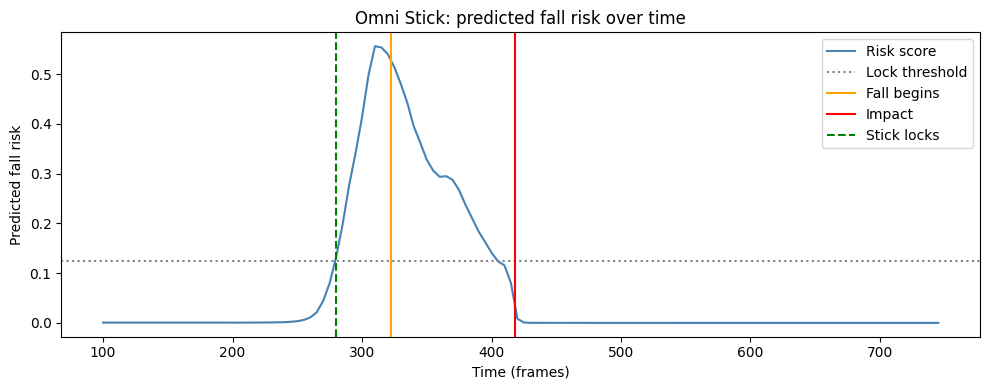

In [32]:
def plot_risk_timeline(signal, fall_onset_idx, impact_idx, model, window_size=WINDOW_SIZE, step=5, threshold=0.5):
    windows, end_indices = make_windows(signal, window_size, step)
    risk_scores = model.predict(windows).flatten()

    plt.figure(figsize=(10, 4))
    plt.plot(end_indices, risk_scores, label='Risk score', color='steelblue')
    plt.axhline(threshold, color='gray', linestyle=':', label='Lock threshold')

    if fall_onset_idx is not None:
        plt.axvline(fall_onset_idx, color='orange', label='Fall begins')
    if impact_idx is not None:
        plt.axvline(impact_idx, color='red', label='Impact')

    above = np.where(risk_scores > threshold)[0]
    if len(above) > 0:
        lock_idx = end_indices[above[0]]
        plt.axvline(lock_idx, color='green', linestyle='--', label='Stick locks')

    plt.xlabel('Time (frames)')
    plt.ylabel('Predicted fall risk')
    plt.title('Omni Stick: predicted fall risk over time')
    plt.legend()
    plt.tight_layout()
    plt.savefig('/content/risk_timeline.png', dpi=150)
    plt.show()

# Uses demo_fall_path / demo_onset / demo_impact found back in Step 6
demo_signal, _, _ = load_trial(demo_fall_path)
plot_risk_timeline(demo_signal, fall_onset_idx=demo_onset, impact_idx=demo_impact, model=model, threshold=FALL_LOCK_THRESHOLD)

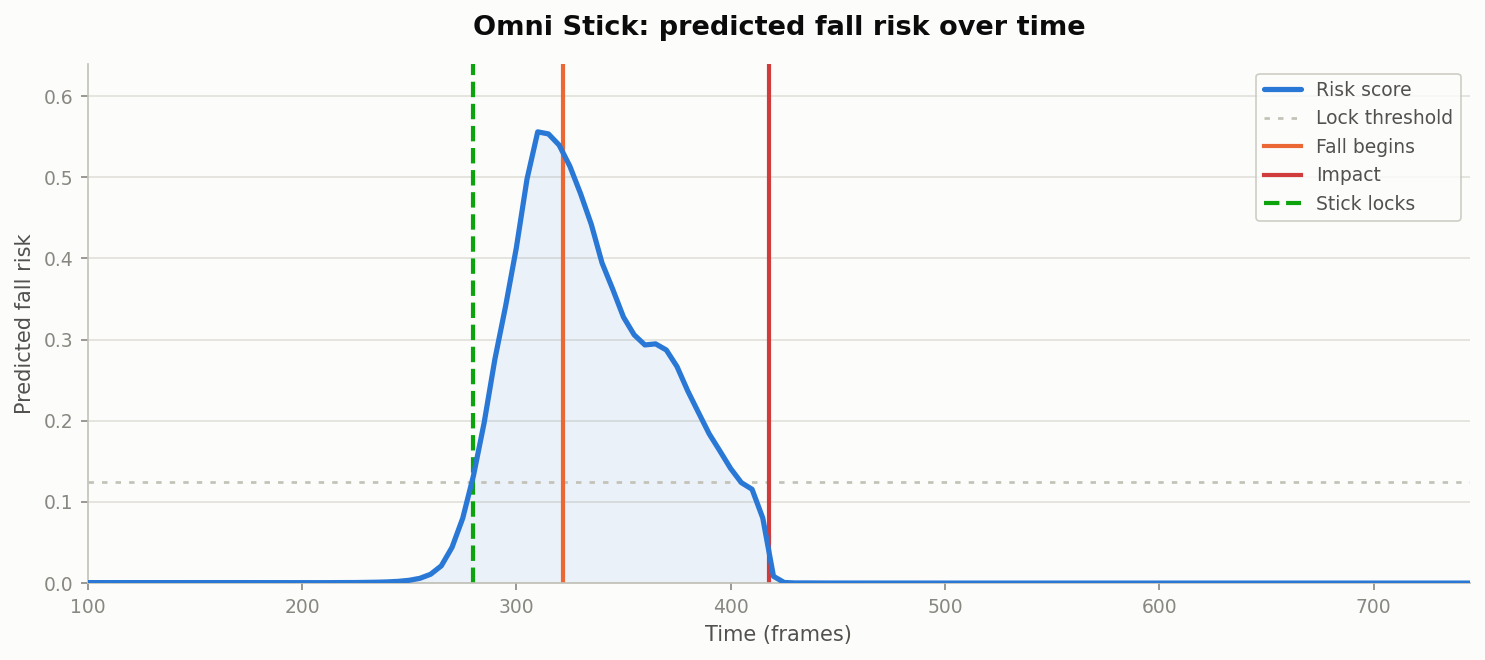

In [36]:
def plot_risk_timeline_styled(signal, fall_onset_idx, impact_idx, model,
                               window_size=WINDOW_SIZE, step=5, threshold=FALL_LOCK_THRESHOLD):
    windows, end_indices = make_windows(signal, window_size, step)
    risk_scores = model.predict(windows, verbose=0).flatten()

    SURFACE, INK, INK_SEC, INK_MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
    GRID, BASELINE = '#e1e0d9', '#c3c2b7'
    SERIES = '#2a78d6'
    GOOD, WARNING, CRITICAL = '#0ca30c', '#eb6834', '#d03b3b'

    fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)

    ax.plot(end_indices, risk_scores, color=SERIES, linewidth=2.5,
            solid_capstyle='round', zorder=3, label='Risk score')
    ax.fill_between(end_indices, risk_scores, 0, color=SERIES, alpha=0.08, zorder=1)

    ax.axhline(threshold, color=BASELINE, linestyle=(0, (2, 3)), linewidth=1.3,
               zorder=2, label='Lock threshold')

    if fall_onset_idx is not None:
        ax.axvline(fall_onset_idx, color=WARNING, linewidth=2, zorder=2, label='Fall begins')
    if impact_idx is not None:
        ax.axvline(impact_idx, color=CRITICAL, linewidth=2, zorder=2, label='Impact')

    above = np.where(risk_scores > threshold)[0]
    if len(above) > 0:
        lock_idx = end_indices[above[0]]
        ax.axvline(lock_idx, color=GOOD, linewidth=2, linestyle='--', zorder=2, label='Stick locks')

    peak = max(risk_scores.max(), threshold)
    ax.set_ylim(0, peak * 1.15)
    ax.set_xlim(end_indices[0], end_indices[-1])

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    ax.set_xlabel('Time (frames)', color=INK_SEC, fontsize=10)
    ax.set_ylabel('Predicted fall risk', color=INK_SEC, fontsize=10)
    ax.set_title('Omni Stick: predicted fall risk over time', color=INK,
                 fontsize=13, fontweight='bold', pad=14)

    legend = ax.legend(loc='upper right', frameon=True, fontsize=9, labelcolor=INK_SEC)
    legend.get_frame().set_facecolor(SURFACE)
    legend.get_frame().set_edgecolor(BASELINE)
    legend.get_frame().set_linewidth(0.8)

    plt.tight_layout()
    plt.savefig('/content/risk_timeline_styled.png', dpi=150, facecolor=SURFACE)
    plt.show()

plot_risk_timeline_styled(demo_signal, fall_onset_idx=demo_onset, impact_idx=demo_impact, model=model)

## 13. Shrink for the microcontroller

Compresses the trained model into a `.tflite` file small and fast enough to run on the chip in the stick's handle.

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('/content/fall_model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"Saved fall_model.tflite ({len(tflite_model)/1024:.1f} KB)")